## Before running this notebook:
If you don't have Xolotl installed yet, refer to https://github.com/ORNL-Fusion/xolotl/wiki/Build-Configuration#quick-start
<br>
<br>
Copy the parameter file ```param_dummy.json``` (from ./xolotl-source/tutorial/inputs/) in your build folder.
<br>
<br>
(Serial) Run the following command in your terminal within the build directory:


```bash
./xolotl param_dummy.json
```
(Parallel) Run the following command in your terminal:

```bash
mpiexec -n 4 ./xolotl param_dummy.json
```
For more information on running Xolotl, see the wiki: https://github.com/ORNL-Fusion/xolotl/wiki/Running-Xolotl

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from   pylab import *
import h5py
from matplotlib.colors import LogNorm
from matplotlib import rcParams 

Modules to load. Most important for extracting data from Xolotl is h5py.

In [2]:
## Set the Zero
zero = 1.0e-20

## Set the maximum size of helium/hydrogen
maxSize = 201

## Open the file
f = h5py.File('xolotlStop.h5', 'r')

## Get the last time step saved in the file
## 'concentrationsGroup/concentration_x_x_x'  
## Depending on version, may only need "ctrlgroup" and "timestep"  ('concentrationsGroup/concentration_x_x')
concGroup = f['concentrationsGroup']
ctrlgroup = concGroup.attrs['lastCtrlStep']
timestep = concGroup.attrs['lastTimeStep']
lastLoop = concGroup.attrs['lastLoop']

"zero" is set to determine the minimum value kept."maxSize" should be from your parameter file. The path to 'xolotlStop.h5' may vary depending on where Xolotl was run. How the data is organized depends on the simulation setup. With the given parameter file, there are 3 groups of data. 

In [3]:
## Open the concentration group
groupName ='concentrationsGroup/concentration_' +str(ctrlgroup) + '_' + str(lastLoop) + '_' + str(timestep-1)
concGroup = f[groupName]

## Read the concentration and index datasets
concDset = concGroup['concs']
indexDset = concGroup['concs_startingIndices']

## Read the time at the chosen time step
time = concGroup.attrs['absoluteTime']

## Read the grid to know which grid point is which depth
gridDset = concGroup['grid']
gridSize = len(gridDset)

## Read how many normal and super clusters there are
networkGroup = f['networkGroup']
totalSize = networkGroup.attrs['totalSize']


"concGroup" and "networkGroup" from h5py are used here to locate and read data from the h5 file. These group and network attribute names may change depending on simulation setup.

In [ ]:
## Create the mesh and data array
x = np.empty([maxSize+1, gridSize])
y = np.empty([maxSize+1, gridSize])
heArray = np.empty([maxSize+1, gridSize])
tArray = np.empty([maxSize+1, gridSize])
vArray = np.empty([maxSize+1, gridSize])
for i in range(0, maxSize+1):
    for j in range(0, gridSize):
        x[i][j] = gridDset[j] - gridDset[1]
        y[i][j] = i
        heArray[i][j] = zero
        tArray[i][j] = zero
        vArray[i][j] = zero
        
## Save the composition information for all clusters
superMap = []
for i in range(0, totalSize):
    ## Get the cluster bounds
    groupName = str(i)
    clusterGroup = networkGroup[groupName]
    bounds = clusterGroup.attrs['bounds']
    temp = [[],[],[]]
    if (bounds[5] > 0): # He + V Case, no other network parameters
        superMap.append(temp)
        continue
    ## Loop on them
    for he in range(bounds[0], bounds[1]+1):
        for v in range(bounds[2], bounds[3]+1):
                    ## Look for he size
                    foundSize = False
                    for j in range(0, len(temp[0])):
                        if (he == temp[0][j][0]):
                            ## Add to the weight
                            temp[0][j][1] = temp[0][j][1] + 1
                            foundSize = True
                            break
                    ## Create a new field
                    if (not foundSize):
                        temp[0].append([he, 1])
                    ## Look for v size
                    foundSize = False
                    for j in range(0, len(temp[1])):
                        if (v == temp[1][j][0]):
                            ## Add to the weight
                            temp[1][j][1] = temp[1][j][1] + 1
                            foundSize = True
                            break
                    ## Create a new field
                    if (not foundSize):
                        temp[1].append([v, 1])

    superMap.append(temp)

## Loop on the grid
for j in range(len(indexDset)-1):
    ## Loop on the concentrations
    for i in range(indexDset[j], indexDset[j+1]):
        ## Skip the moments for now
        if (int(concDset[i][0]) > totalSize - 1): continue
        ## Get the concentration
        conc = concDset[i][1]
        ## Loop on each component
        lists = superMap[concDset[i][0]]
        #print(lists)
        ## He
        for k in range(0, len(lists[0])):
            heSize = lists[0][k][0]
            heArray[heSize][j] = heArray[heSize][j] + (conc * lists[0][k][1])
        ## V
        for k in range(0, len(lists[1])): # Change 2 -> 1
            vSize = lists[1][k][0]
            vArray[vSize][j] = vArray[vSize][j] + (conc * lists[1][k][1]) # Change 2 -> 1



This block takes the h5 data and organizes it for plotting. This code is simplified to just include He and V since this these are the only network parameters for the example param file. Other parameters to the network can be added with similar lines of code. You will need to ensure the cluster bounds are correct when retrieving and organizing data. 

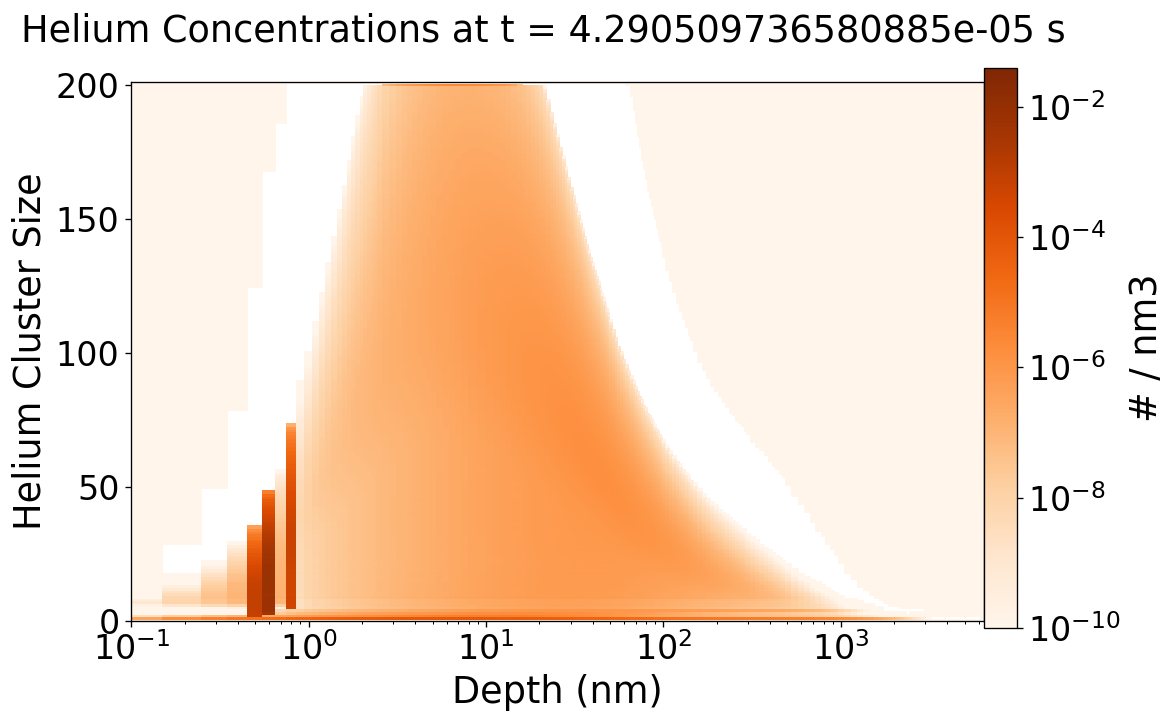

In [7]:
## Create plots
DPI, FIG_WIDTH, FIG_HEIGHT = 120, 1100, 700
fig, ax = plt.subplots(figsize=(FIG_WIDTH / DPI, FIG_HEIGHT / DPI), dpi=DPI)

title = 'Helium Concentrations at t = ' + str(time) + ' s'
fig.suptitle(title,fontsize=22)
hePlot = plt.subplot(111)
zMaxPlus = max(heArray.max(), max(tArray.max(), vArray.max()))
heMasked = np.ma.masked_where(heArray <= 0, heArray)
## Plot the data
cb1 = hePlot.pcolor(
    x, y, heMasked,
    norm=LogNorm(vmin=1.0e-10, vmax=zMaxPlus),
    cmap="Oranges",
    alpha=1.0
)
#cb1 = hePlot.pcolor(x, y, heArray, vmin=-zMaxPlus, vmax=zMaxPlus, cmap="bwr", alpha=1.0)
hePlot.set_xlabel("Depth (nm)",fontsize=22)
hePlot.set_ylabel("Helium Cluster Size",fontsize=22)
hePlot.set_xlim([0.1, gridDset[len(gridDset)-1] - gridDset[1]])
hePlot.set_ylim([0, maxSize])
hePlot.set_xscale('log')
hePlot.tick_params(axis='both', which='major', labelsize=20)

## Make an axis for the colorbar on the right side
cax = fig.add_axes([0.9, 0.1, 0.03, 0.8])
colorbar1 = plt.colorbar(cb1, cax=cax)
colorbar1.set_label("# / nm3",fontsize=22)
colorbar1.ax.tick_params(axis='y',labelsize=20)

#fig.savefig('He_cong.png')

plt.show()


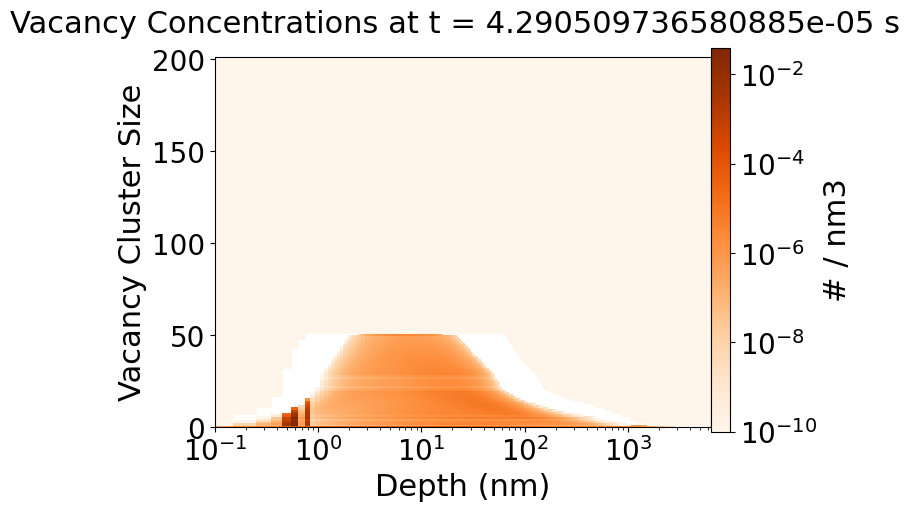

In [ ]:

## Create plots
fig3 = plt.figure()
title = 'Vacancy Concentrations at t = ' + str(time) + ' s'
fig3.suptitle(title,fontsize=22)
vPlot = plt.subplot(111)

## Plot the data
cb3 = vPlot.pcolor(x, y, vArray, norm=LogNorm(vmin=1.0e-10, vmax=zMaxPlus), cmap="Oranges", alpha=1.0)
#cb3 = vPlot.pcolor(x, y, vArray, vmin=-zMaxPlus, vmax=zMaxPlus, cmap="bwr", alpha=1.0)
vPlot.set_xlabel("Depth (nm)",fontsize=22)
vPlot.set_ylabel("Vacancy Cluster Size",fontsize=22)
vPlot.set_xlim([0.1, gridDset[len(gridDset)-1] - gridDset[1]])
vPlot.set_ylim([0, maxSize])
vPlot.set_xscale('log')
vPlot.tick_params(axis='both', which='major', labelsize=20)

## Make an axis for the colorbar on the right side
cax = fig3.add_axes([0.9, 0.1, 0.03, 0.8])
colorbar3 = plt.colorbar(cb3, cax=cax)
colorbar3.set_label("# / nm3",fontsize=22)
colorbar3.ax.tick_params(axis='y',labelsize=20)

#fig3.savefig('V_cong.png')

## Show the plots
plt.show()